# Disaster effects prediction and insight with NSF

**steps**:
- load the disaster dataset and feats dataset
- combine them
- make a dataset for each disaster type
- for each type (starting with only one):
    * standardize and normalize the features
    * define the NSF model
    * train the model
    * inspect the resulting distribution
    * see the conditioning features effects

**dataset design**:
- one dataframe per event type
- time reference feat as ...
- no topographical feat as coords, not state/county
- geographical and natural feats for conditioning
- casualties and damages as y 

#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
from scipy import stats
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [2]:
DATASET_PATH = Path("../datasets/disasters_new_feats/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation

In [3]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [4]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [5]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [6]:
event_group_dfs['Hail'].head()

,Unnamed: 0,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


In [7]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [8]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE',
]

In [9]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [10]:
# targets log transformation
Y = np.log1p(Y)

In [11]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [12]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [13]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [14]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

In [15]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization and Dataset creation

In [16]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [17]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [18]:
# targets log transformation
Y = np.log1p(Y)

In [19]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [20]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


In [21]:
# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [22]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

### Model definition

In [23]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [24]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

In [25]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [26]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


### Model Loading

In [27]:
flow.load_state_dict(torch.load(RUN_PATH))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

C:\Users\xPica\AppData\Local\Temp\ipykernel_1420\4212689827.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load(RUN_PATH))


### Model Evaluation

In [28]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


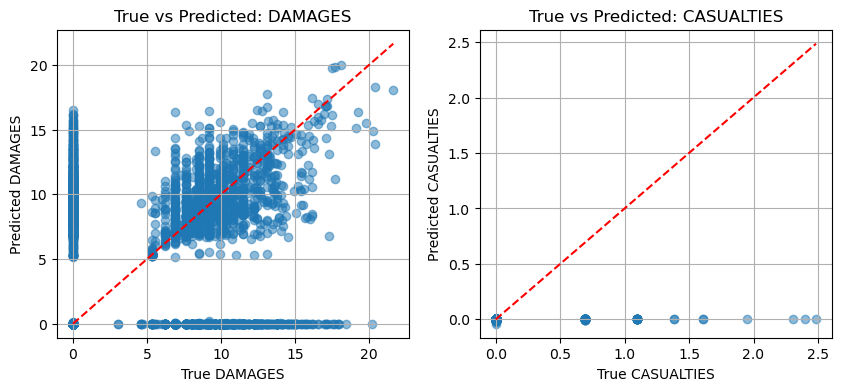

In [29]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

## Result Analysis — Monte Carlo CI and Calibration

Using the NSF's distributional output: Monte Carlo sampling for confidence intervals, coverage analysis, and uncertainty–feature correlation.

In [30]:
def batch_mc_samples(flow, X_test, Y_test, y_scaler, n_samples=2000, device='cpu'):
    """
    Draw Monte Carlo samples from the NSF for each test point.
    Returns samples and true values in original scale (after expm1).
    """
    flow.eval()
    X_test = X_test.to(device)
    n_test = X_test.shape[0]
    all_samples = np.zeros((n_test, n_samples, 2), dtype=np.float32)

    with torch.no_grad():
        for i in range(n_test):
            x = X_test[i:i+1]  # (1, X_DIM)
            dist = flow(x)
            samples = dist.sample((n_samples,)).squeeze(1).cpu().numpy()  # (n_samples, 2)
            samples = y_scaler.inverse_transform(samples)
            samples = np.expm1(np.clip(samples, -20, None))
            samples[:, 1] = np.floor(samples[:, 1]).clip(0)  # CASUALTIES non-negative
            all_samples[i] = samples

    y_true_scaled = Y_test.cpu().numpy()
    y_true_orig = y_scaler.inverse_transform(y_true_scaled)
    y_true_orig = np.expm1(np.clip(y_true_orig, -20, None))
    y_true_orig[:, 1] = np.floor(y_true_orig[:, 1]).clip(0)

    return all_samples, y_true_orig

In [31]:
N_MC_SAMPLES = 2000
all_samples, y_true_orig = batch_mc_samples(flow, X_test, Y_test, y_scaler, n_samples=N_MC_SAMPLES, device=device)
print(f"all_samples shape: {all_samples.shape}, y_true_orig shape: {y_true_orig.shape}")

all_samples shape: (7454, 2000, 2), y_true_orig shape: (7454, 2)


### Calibration: Empirical CI Coverage

Does the model produce well-calibrated intervals? For 50%, 80%, and 95% CIs, we check whether the true value falls inside.

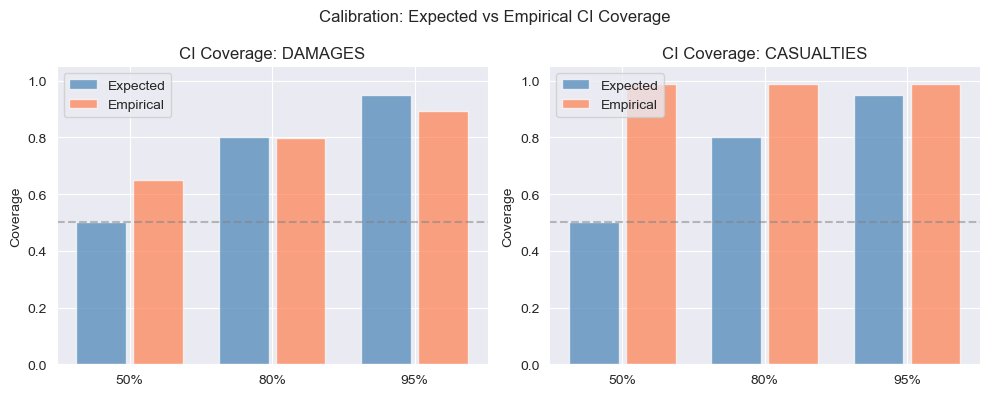

In [32]:
ci_levels = [0.50, 0.80, 0.95]
coverage = {col: [] for col in TARGET_COLS}

for level in ci_levels:
    lo = (1 - level) / 2
    hi = 1 - lo
    for j, col in enumerate(TARGET_COLS):
        q_lo = np.percentile(all_samples[:, :, j], lo * 100, axis=1)
        q_hi = np.percentile(all_samples[:, :, j], hi * 100, axis=1)
        inside = (y_true_orig[:, j] >= q_lo) & (y_true_orig[:, j] <= q_hi)
        coverage[col].append(inside.mean())

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (col, cov) in zip(axes, coverage.items()):
    x = np.arange(len(ci_levels))
    bars = ax.bar(x - 0.2, ci_levels, 0.35, label='Expected', alpha=0.7, color='steelblue')
    bars2 = ax.bar(x + 0.2, cov, 0.35, label='Empirical', alpha=0.7, color='coral')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(l*100)}%' for l in ci_levels])
    ax.set_ylabel('Coverage')
    ax.set_title(f'CI Coverage: {col}')
    ax.legend()
    ax.set_ylim(0, 1.05)
plt.suptitle('Calibration: Expected vs Empirical CI Coverage')
plt.tight_layout()
plt.show()

### PIT Histogram (Probability Integral Transform)

For each test point, we compute the percentile rank of the true value within the sampled distribution. A well-calibrated model yields a uniform histogram.

**If the PIT looks Gaussian (central bulge) instead of uniform, possible causes:**
- **Underconfidence**: Predicted distributions are too wide; true values often fall near the median, clustering PIT around 0.5.
- **Regression to the mean**: In heavy-tailed data, extreme true values may be underpredicted; moderate values overpredicted.
- **Model misfit**: The flow may not fully capture the conditional variance structure.

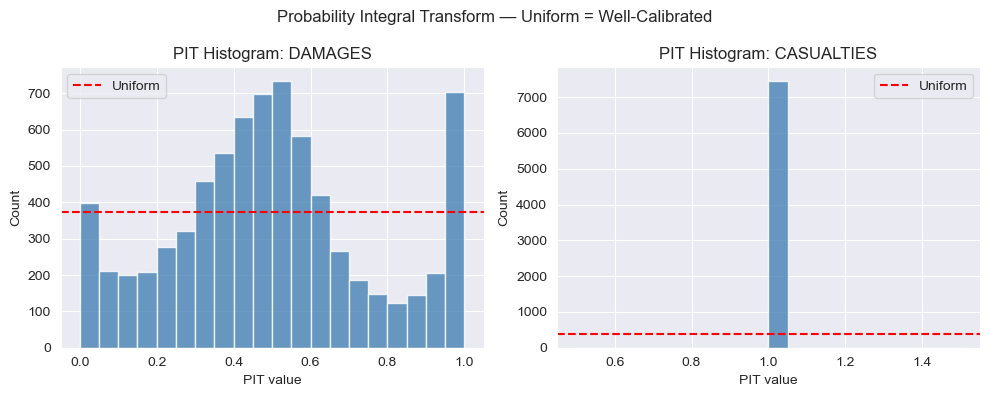

In [33]:
pit_values = np.zeros_like(y_true_orig)
for i in range(len(y_true_orig)):
    for j in range(2):
        pit_values[i, j] = np.mean(all_samples[i, :, j] <= y_true_orig[i, j])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (col, j) in zip(axes, [(TARGET_COLS[0], 0), (TARGET_COLS[1], 1)]):
    ax.hist(pit_values[:, j], bins=20, edgecolor='white', alpha=0.8, color='steelblue')
    ax.axhline(len(pit_values) / 20, color='red', linestyle='--', label='Uniform')
    ax.set_xlabel('PIT value')
    ax.set_ylabel('Count')
    ax.set_title(f'PIT Histogram: {col}')
    ax.legend()
plt.suptitle('Probability Integral Transform — Uniform = Well-Calibrated')
plt.tight_layout()
plt.show()

### Individual Conditional Distributions

Three representative events: low, medium, and high damage. MC samples with KDE density coloring; true value marked in red.

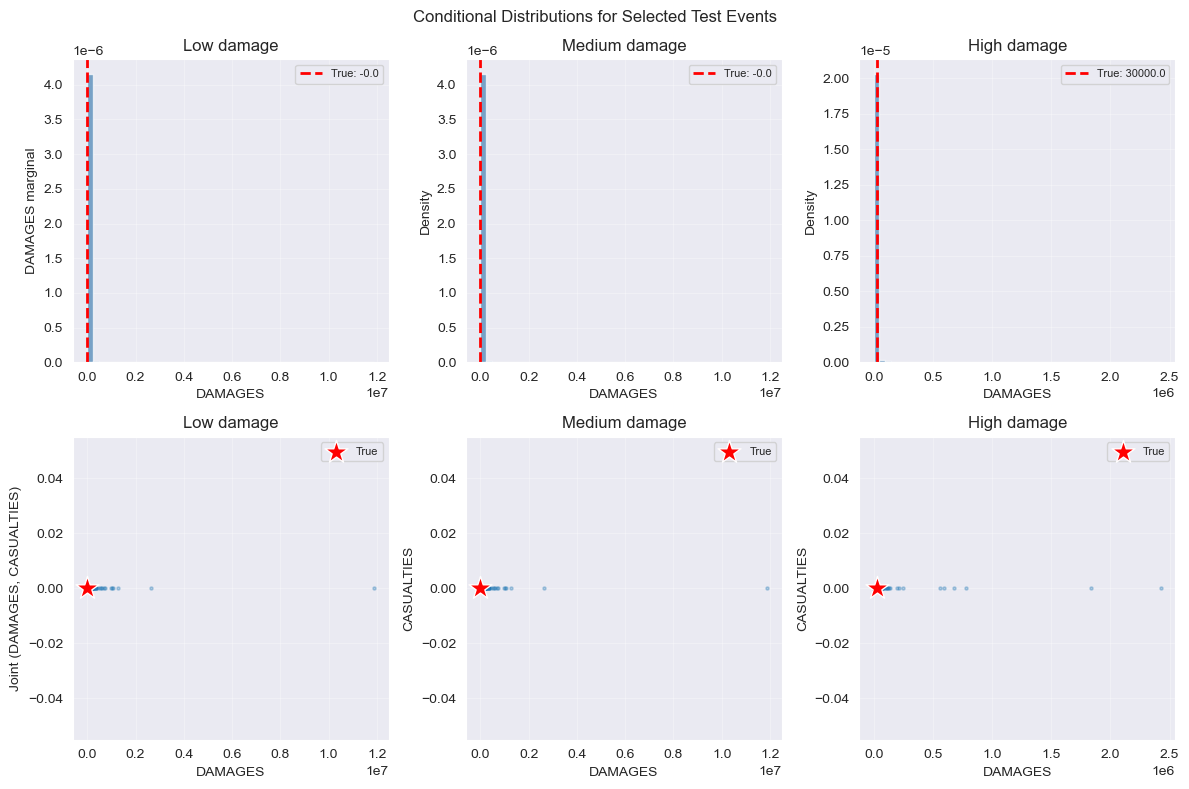

In [34]:
# Select low, medium, high damage indices by DAMAGES
damages = y_true_orig[:, 0]
q_low = np.percentile(damages, 10)
q_mid = np.percentile(damages, 50)
q_hi = np.percentile(damages, 90)
idx_low = np.argmin(np.abs(damages - q_low))
idx_mid = np.argmin(np.abs(damages - q_mid))
idx_hi = np.argmin(np.abs(damages - q_hi))
indices = [idx_low, idx_mid, idx_hi]
labels = ['Low damage', 'Medium damage', 'High damage']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, (ax_row, j) in enumerate(zip(axes, [0, 1])):
    for ax, (idx, lbl) in zip(ax_row, zip(indices, labels)):
        samples_j = all_samples[idx, :, j]
        true_val = y_true_orig[idx, j]
        if col == 0:
            ax.hist(samples_j, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
            ax.axvline(true_val, color='red', linewidth=2, linestyle='--', label=f'True: {true_val:.1f}')
        else:
            # 2D: DAMAGES vs CASUALTIES for this sample
            s0, s1 = all_samples[idx, :, 0], all_samples[idx, :, 1]
            try:
                xy = np.vstack([s0, s1])
                z = gaussian_kde(xy)(xy)
                ax.scatter(s0, s1, c=z, s=5, cmap='viridis', alpha=0.6)
            except np.linalg.LinAlgError:
                ax.scatter(s0, s1, alpha=0.3, s=5)
            ax.scatter(y_true_orig[idx, 0], y_true_orig[idx, 1], marker='*', s=300, c='red', edgecolor='white', zorder=5, label='True')
        ax.set_title(f'{lbl}')
        if col == 0:
            ax.set_xlabel(TARGET_COLS[j])
            ax.set_ylabel('Density')
        else:
            ax.set_xlabel(TARGET_COLS[0])
            ax.set_ylabel(TARGET_COLS[1])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
axes[0, 0].set_ylabel('DAMAGES marginal')
axes[1, 0].set_ylabel('Joint (DAMAGES, CASUALTIES)')
plt.suptitle('Conditional Distributions for Selected Test Events')
plt.tight_layout()
plt.show()

### Uncertainty vs Input Features

Which input conditions correlate with wider (higher uncertainty) or narrower (higher confidence) 95% CIs?

C:\Users\xPica\AppData\Local\Temp\ipykernel_1420\2612865304.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_c, _ = stats.spearmanr(X_test_orig[:, k], ci_width_casualties)
C:\Users\xPica\AppData\Local\Temp\ipykernel_1420\2612865304.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_d, _ = stats.spearmanr(X_test_orig[:, k], ci_width_damages)


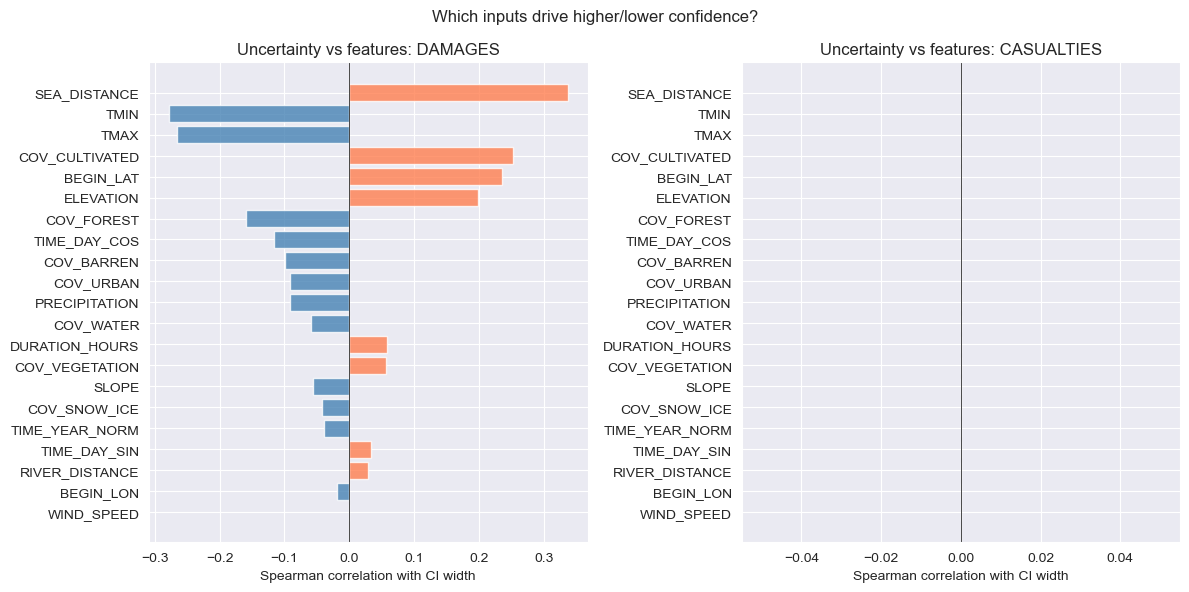

In [35]:
# 95% CI width for each test point and target
ci_lo, ci_hi = np.percentile(all_samples, [2.5, 97.5], axis=1)
ci_width_damages = np.log1p(ci_hi[:, 0]) - np.log1p(ci_lo[:, 0])  # log-scale width more interpretable
ci_width_casualties = ci_hi[:, 1] - ci_lo[:, 1]

X_test_orig = x_scaler.inverse_transform(X_test.cpu().numpy())
corr_damages = []
corr_casualties = []
for k in range(X_test_orig.shape[1]):
    r_d, _ = stats.spearmanr(X_test_orig[:, k], ci_width_damages)
    r_c, _ = stats.spearmanr(X_test_orig[:, k], ci_width_casualties)
    corr_damages.append(np.nan_to_num(r_d, nan=0.0))
    corr_casualties.append(np.nan_to_num(r_c, nan=0.0))

df_corr = pd.DataFrame({
    'feature': X_COLS,
    'DAMAGES': corr_damages,
    'CASUALTIES': corr_casualties
})
df_corr['abs_D'] = np.abs(df_corr['DAMAGES'])
df_corr = df_corr.sort_values('abs_D', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors_d = ['coral' if c > 0 else 'steelblue' for c in df_corr['DAMAGES']]
colors_c = ['coral' if c > 0 else 'steelblue' for c in df_corr['CASUALTIES']]
axes[0].barh(df_corr['feature'], df_corr['DAMAGES'], color=colors_d, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Spearman correlation with CI width')
axes[0].set_title(f'Uncertainty vs features: {TARGET_COLS[0]}')
axes[1].barh(df_corr['feature'], df_corr['CASUALTIES'], color=colors_c, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Spearman correlation with CI width')
axes[1].set_title(f'Uncertainty vs features: {TARGET_COLS[1]}')
plt.suptitle('Which inputs drive higher/lower confidence?')
plt.tight_layout()
plt.show()

### Conditional Sensitivity: How Outputs Change with Key Features

Fix all features at the median; sweep each feature from 5th to 95th percentile. DAMAGES only, 2 plots per row.

In [36]:
print(X_COLS)

['BEGIN_LAT', 'BEGIN_LON', 'DURATION_HOURS', 'WIND_SPEED', 'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM', 'PRECIPITATION', 'TMIN', 'TMAX', 'ELEVATION', 'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION', 'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN', 'RIVER_DISTANCE', 'SEA_DISTANCE']


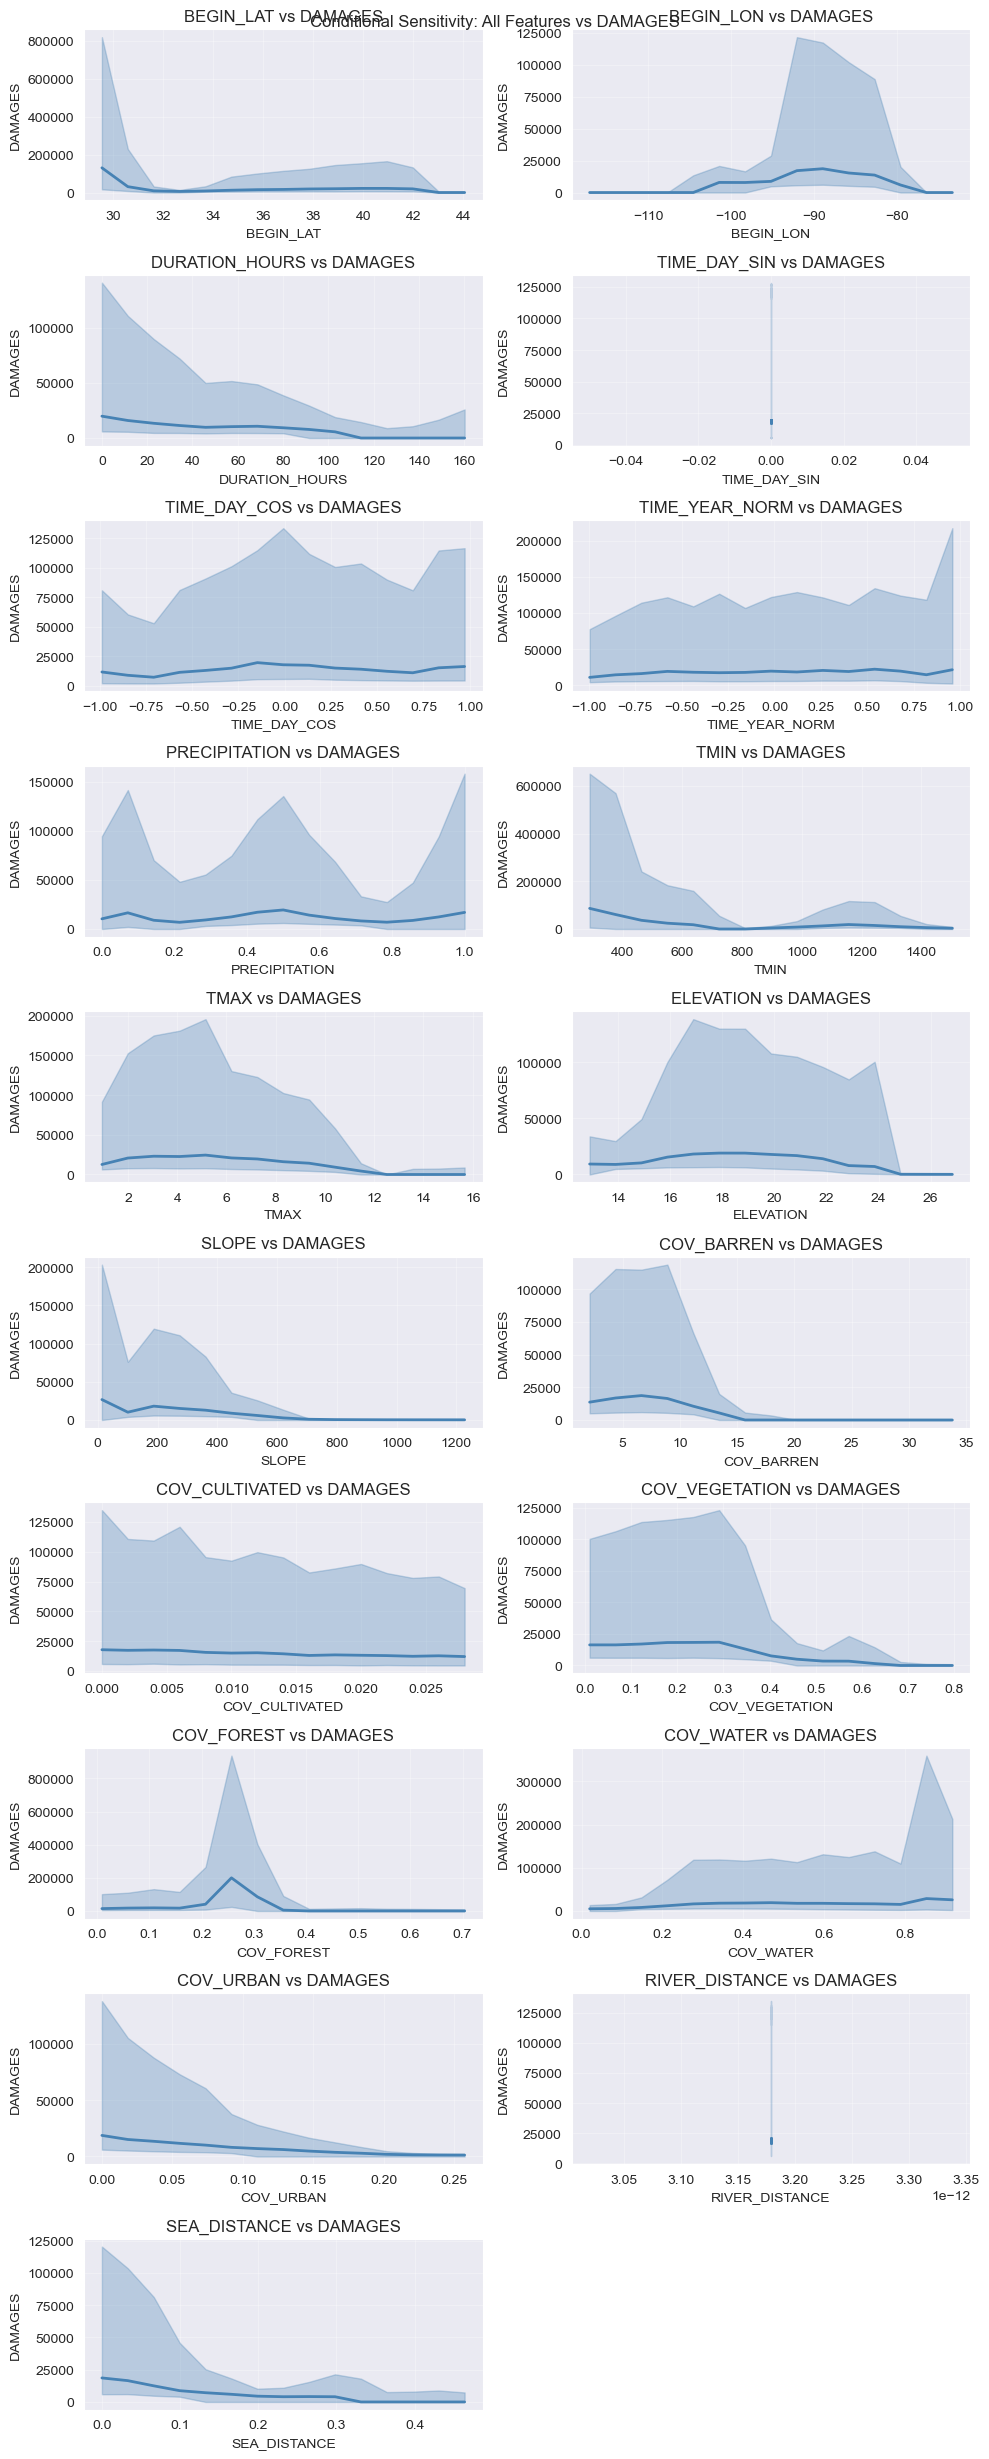

In [37]:
# Median context (scaled)
x_median = np.median(X_test_orig, axis=0)
n_sweep = 15
n_samples_sweep = 2000
j = 0  # DAMAGES only

used_features =['BEGIN_LAT', 'BEGIN_LON', 'DURATION_HOURS', 'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM', 'PRECIPITATION', 'TMIN', 'TMAX', 'ELEVATION', 'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION', 'COV_FOREST', 'COV_WATER', 'COV_URBAN', 'RIVER_DISTANCE', 'SEA_DISTANCE']

n_features = len(used_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.5 * n_rows))
axes = np.atleast_2d(axes)

for idx, (feat_name, feat_idx) in enumerate(zip(used_features, range(n_features))):
    ax = axes.flat[idx]
    vals_orig = np.linspace(np.percentile(X_test_orig[:, feat_idx], 5),
                            np.percentile(X_test_orig[:, feat_idx], 95), n_sweep)
    medians, lo80, hi80 = [], [], []
    for v in vals_orig:
        x_ctx = x_median.copy()
        x_ctx[feat_idx] = v
        x_scaled = torch.tensor(x_scaler.transform(x_ctx.reshape(1, -1)), dtype=torch.float32).to(device)
        with torch.no_grad():
            dist = flow(x_scaled)
            samples = dist.sample((n_samples_sweep,)).squeeze(1).cpu().numpy()
        samples = y_scaler.inverse_transform(samples)
        samples = np.expm1(np.clip(samples, -20, None))
        samples[:, 1] = np.floor(samples[:, 1]).clip(0)
        medians.append(np.median(samples[:, j]))
        lo80.append(np.percentile(samples[:, j], 10))
        hi80.append(np.percentile(samples[:, j], 90))
    medians, lo80, hi80 = np.array(medians), np.array(lo80), np.array(hi80)
    ax.fill_between(vals_orig, lo80, hi80, alpha=0.3, color='steelblue')
    ax.plot(vals_orig, medians, color='steelblue', linewidth=2)
    ax.set_xlabel(feat_name)
    ax.set_ylabel(TARGET_COLS[0])
    ax.set_title(f'{feat_name} vs {TARGET_COLS[0]}')
    ax.grid(True, alpha=0.3)

for idx in range(n_features, n_rows * n_cols):
    axes.flat[idx].set_visible(False)
plt.suptitle('Conditional Sensitivity: All Features vs DAMAGES')
plt.tight_layout()
plt.show()

### Geographic Calibration Map

Events colored by which targets fall inside the CI: both correct (green), damages only (blue), casualties only (orange), both wrong (red). Separate map for each coverage level.

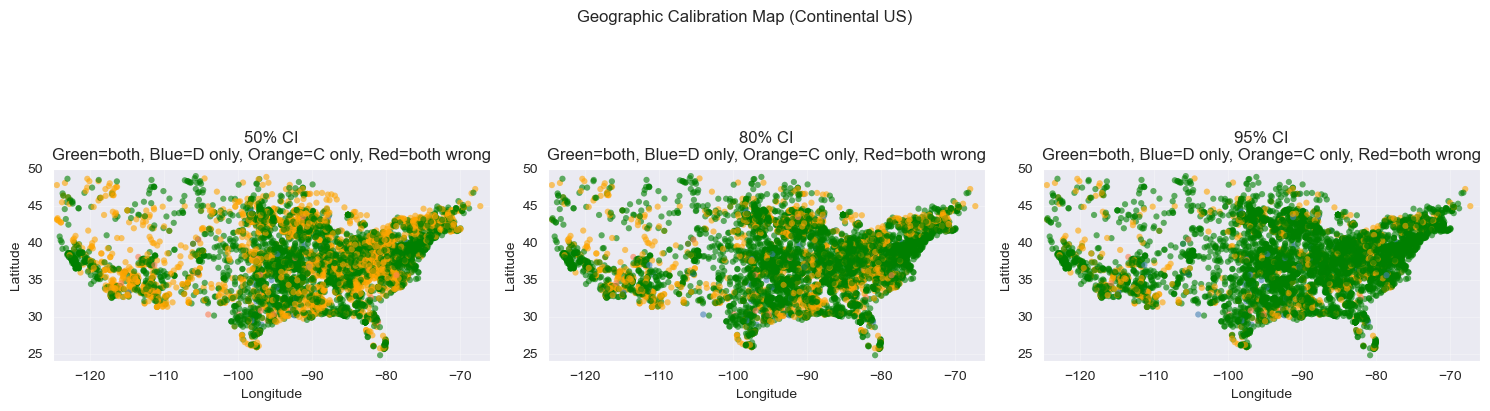

In [38]:
lat_idx = X_COLS.index('BEGIN_LAT')
lon_idx = X_COLS.index('BEGIN_LON')
lats = X_test_orig[:, lat_idx]
lons = X_test_orig[:, lon_idx]

# Continental US bounds (approx)
LAT_MIN, LAT_MAX = 24, 50
LON_MIN, LON_MAX = -125, -66
mask_us = (lats >= LAT_MIN) & (lats <= LAT_MAX) & (lons >= LON_MIN) & (lons <= LON_MAX)
lats_us, lons_us = lats[mask_us], lons[mask_us]

# Coverage levels: (level_name, lo_pct, hi_pct)
coverage_configs = [(50, 25, 75), (80, 10, 90), (95, 2.5, 97.5)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (level, lo, hi) in zip(axes, coverage_configs):
    inside_d = (y_true_orig[:, 0] >= np.percentile(all_samples[:, :, 0], lo, axis=1)) & \
               (y_true_orig[:, 0] <= np.percentile(all_samples[:, :, 0], hi, axis=1))
    inside_c = (y_true_orig[:, 1] >= np.percentile(all_samples[:, :, 1], lo, axis=1)) & \
               (y_true_orig[:, 1] <= np.percentile(all_samples[:, :, 1], hi, axis=1))
    inside_d_us = inside_d[mask_us]
    inside_c_us = inside_c[mask_us]

    # 4 categories: both, damages only, casualties only, both wrong
    both_ok = inside_d_us & inside_c_us
    d_only = inside_d_us & ~inside_c_us
    c_only = ~inside_d_us & inside_c_us
    both_wrong = ~inside_d_us & ~inside_c_us

    colors = np.where(both_ok, 'green', np.where(d_only, 'steelblue', np.where(c_only, 'orange', 'coral')))
    ax.scatter(lons_us, lats_us, c=colors, alpha=0.6, s=20, edgecolors='none')
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'{level}% CI\nGreen=both, Blue=D only, Orange=C only, Red=both wrong')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.suptitle('Geographic Calibration Map (Continental US)')
plt.tight_layout()
plt.show()

### Geographic CI Width Map

Events colored by 95% CI width (gradient): dark = narrow/confident, bright = wide/uncertain.

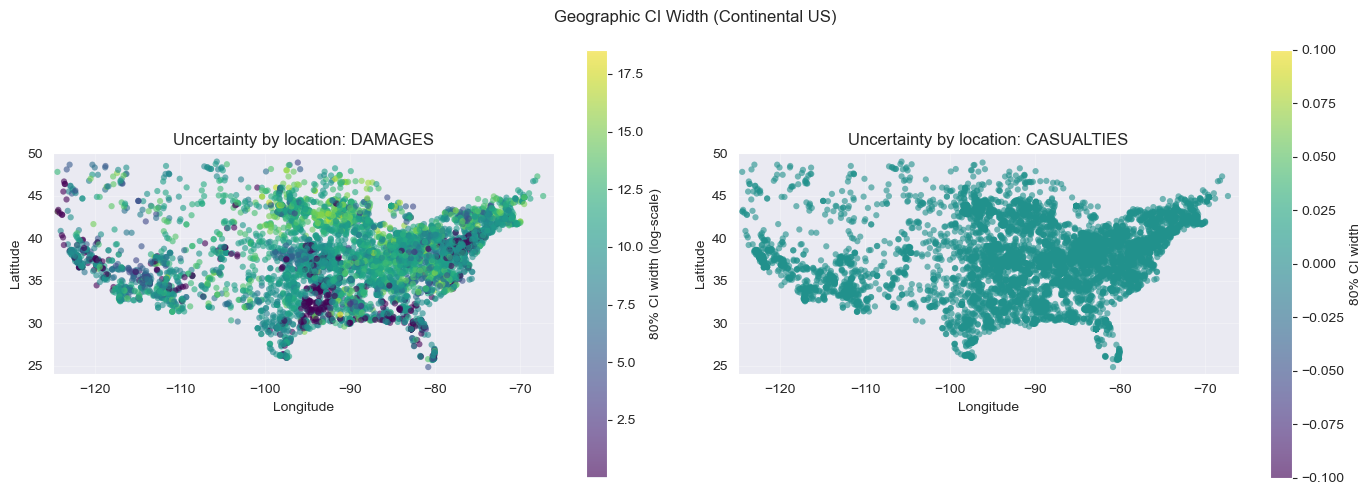

In [47]:
ci_width_damages_us = ci_width_damages[mask_us]
ci_width_casualties_us = ci_width_casualties[mask_us]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (widths, col, label) in zip(axes, [(ci_width_damages_us, TARGET_COLS[0], '80% CI width (log-scale)'),
                                            (ci_width_casualties_us, TARGET_COLS[1], '80% CI width')]):
    sc = ax.scatter(lons_us, lats_us, c=widths, cmap='viridis', alpha=0.6, s=20, edgecolors='none')
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Uncertainty by location: {col}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=label)
plt.suptitle('Geographic CI Width (Continental US)')
plt.tight_layout()
plt.show()

### True vs Predicted Colored by CI Width

Scatter of true vs predicted median; color indicates uncertainty (CI width). Reveals whether high-uncertainty predictions correlate with larger errors.

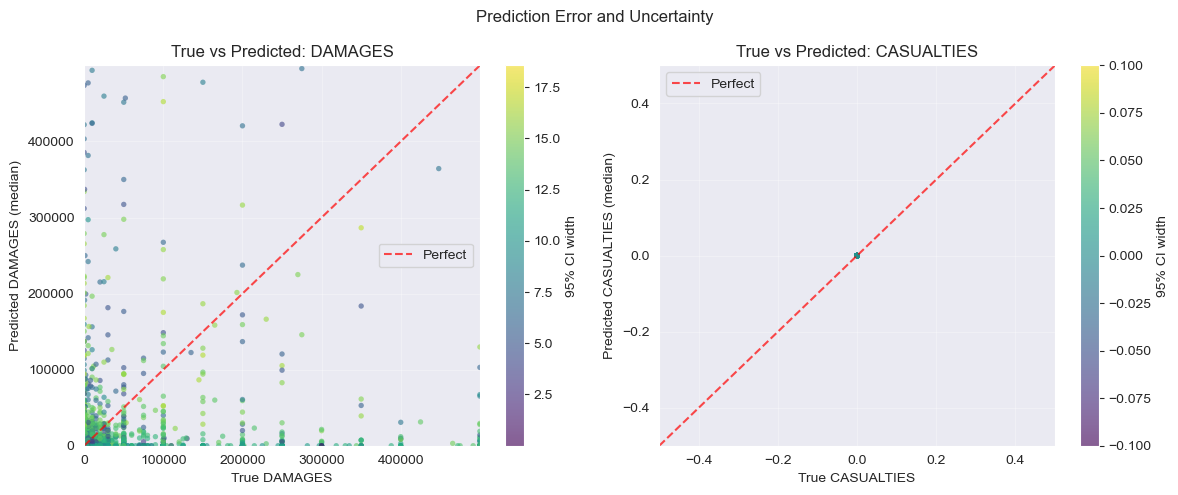

In [48]:
pred_median = np.median(all_samples, axis=1)  # (n_test, 2)

# Percentile-based limits to avoid outliers zooming out the view (2nd-98th)
PCT_LO, PCT_HI = 2, 98

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (j, col) in zip(axes, enumerate(TARGET_COLS)):
    widths = ci_width_damages if j == 0 else ci_width_casualties
    sc = ax.scatter(y_true_orig[:, j], pred_median[:, j], c=widths, cmap='viridis', alpha=0.6, s=15, edgecolors='none')
    both = np.concatenate([y_true_orig[:, j], pred_median[:, j]])
    lim_lo = np.percentile(both, PCT_LO)
    lim_hi = np.percentile(both, PCT_HI)
    if lim_lo >= lim_hi:
        pad = max(1e-6, np.abs(lim_lo) * 0.01) if lim_lo != 0 else 0.5
        lim_lo, lim_hi = lim_lo - pad, lim_hi + pad
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'r--', alpha=0.7, label='Perfect')
    ax.set_xlabel(f'True {col}')
    ax.set_ylabel(f'Predicted {col} (median)')
    ax.set_title(f'True vs Predicted: {col}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='95% CI width')
plt.suptitle('Prediction Error and Uncertainty')
plt.tight_layout()
plt.show()

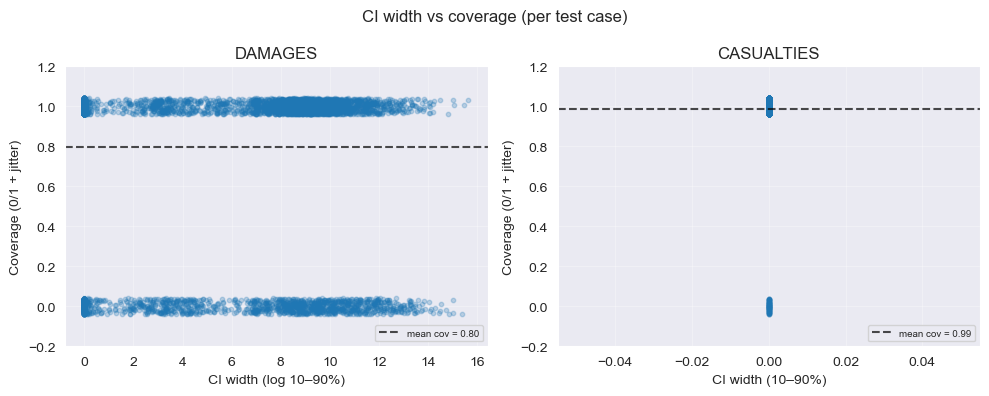

In [49]:
# CI width vs coverage infographic (10–90% intervals)
# Uses Monte Carlo CIs from `all_samples` / `y_true_orig`.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rng = np.random.default_rng(0)

for ax, target_idx in zip(axes, [0, 1]):
    name = TARGET_COLS[target_idx]
    y_true = y_true_orig[:, target_idx]

    # 10–90% CI from MC samples
    q10 = np.percentile(all_samples[:, :, target_idx], 10, axis=1)
    q90 = np.percentile(all_samples[:, :, target_idx], 90, axis=1)

    # Width: log-scale for damages, raw for casualties (matches earlier plots)
    if target_idx == 0:
        width = np.log1p(q90) - np.log1p(q10)
        x_label = "CI width (log 10–90%)"
    else:
        width = q90 - q10
        x_label = "CI width (10–90%)"

    cover = ((y_true >= q10) & (y_true <= q90)).astype(float)
    jitter = (rng.random(len(width)) - 0.5) * 0.08

    ax.scatter(width, cover + jitter, alpha=0.25, s=10, c="C0")
    ax.axhline(cover.mean(), color="k", ls="--", alpha=0.7,
               label=f"mean cov = {cover.mean():.2f}")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Coverage (0/1 + jitter)")
    ax.set_title(name)
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle("CI width vs coverage (per test case)")
plt.tight_layout()
plt.show()

C:\Users\xPica\AppData\Local\Temp\ipykernel_1420\4068877341.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(widths_by_level, labels=labels, showfliers=False)


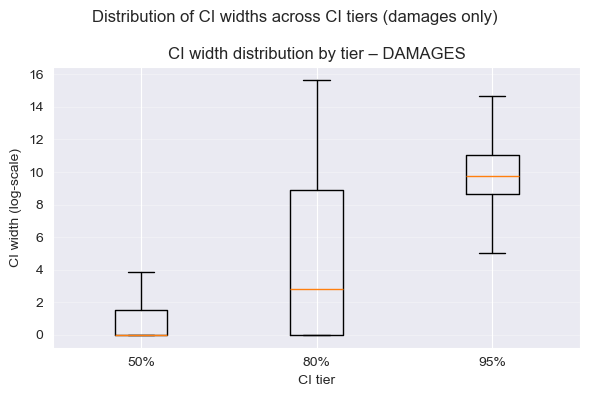

In [52]:
# CI width distribution across CI tiers (damages only)

ci_levels = [0.50, 0.80, 0.95]

fig, ax = plt.subplots(figsize=(6, 4))

target_idx = 0  # damages only
name = TARGET_COLS[target_idx]

widths_by_level = []
labels = []

for level in ci_levels:
    lo = (1 - level) / 2 * 100
    hi = (1 + level) / 2 * 100

    q_lo = np.percentile(all_samples[:, :, target_idx], lo, axis=1)
    q_hi = np.percentile(all_samples[:, :, target_idx], hi, axis=1)

    # Log-width for damages
    widths = np.log1p(q_hi) - np.log1p(q_lo)

    widths_by_level.append(widths)
    labels.append(f"{int(level * 100)}%")

ax.boxplot(widths_by_level, labels=labels, showfliers=False)
ax.set_xlabel("CI tier")
ax.set_ylabel("CI width (log-scale)")
ax.set_title(f"CI width distribution by tier – {name}")
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Distribution of CI widths across CI tiers (damages only)")
plt.tight_layout()
plt.show()

### Geographic CI Width Map (80% CI, log color scale)

Events colored by **80% CI width**; color is on a **logarithmic scale** (dark = narrow/confident, bright = wide/uncertain).

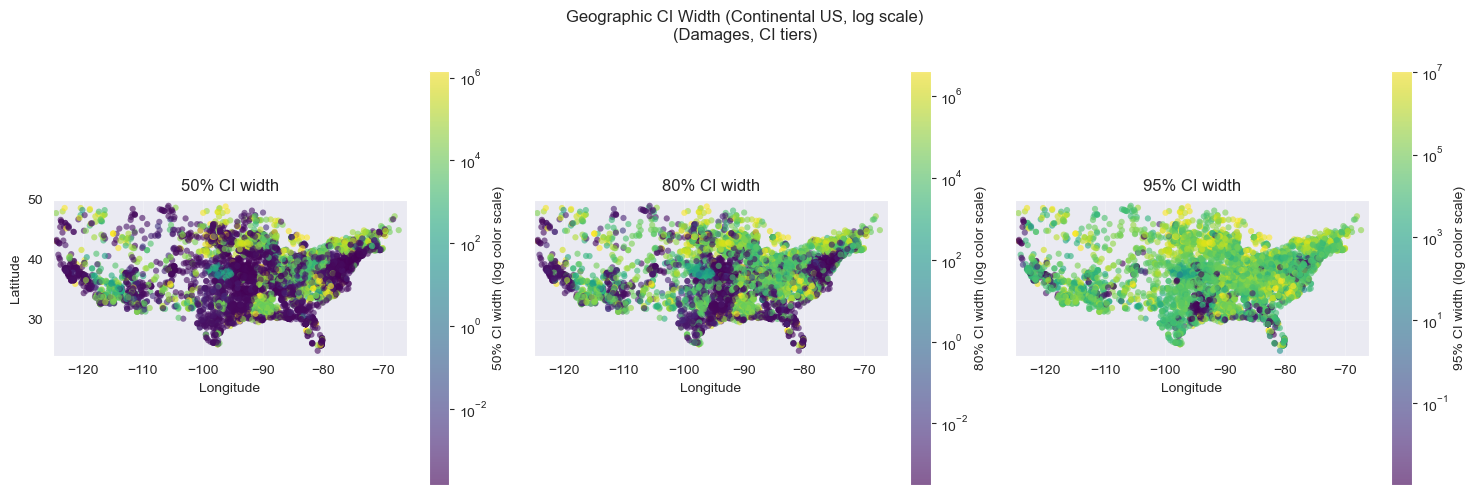

In [60]:
# CI Width maps for various CI tiers (log color scale) – subplot for each ci_level

ci_levels = [0.50, 0.80, 0.95]
level_names = [f"{int(level*100)}%" for level in ci_levels]
target_idx = 0  # damages only, as in prompt

n_levels = len(ci_levels)
fig, axes = plt.subplots(1, n_levels, figsize=(5 * n_levels, 5), sharex=True, sharey=True)

if n_levels == 1:
    axes = [axes]  # in case of single level

for i, (level, name, ax) in enumerate(zip(ci_levels, level_names, axes)):
    lo = (1 - level) / 2 * 100
    hi = (1 + level) / 2 * 100

    q_lo = np.percentile(all_samples[:, :, target_idx], lo, axis=1)
    q_hi = np.percentile(all_samples[:, :, target_idx], hi, axis=1)
    ci_width = q_hi - q_lo  # on original scale

    ci_width_us = ci_width[mask_us]

    # Avoid zeros for log normalization
    positive = ci_width_us[ci_width_us > 0]
    if positive.size == 0:
        vmin = 1e-6
        vmax = 1.0
    else:
        vmin = np.percentile(positive, 1)
        vmax = np.percentile(positive, 99)
        if vmin <= 0:
            vmin = positive.min() * 0.5

    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    sc = ax.scatter(
        lons_us,
        lats_us,
        c=ci_width_us,
        cmap="viridis",
        norm=norm,
        alpha=0.6,
        s=20,
        edgecolors="none",
    )
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel("Longitude")
    if i == 0:
        ax.set_ylabel("Latitude")
    ax.set_title(f"{name} CI width")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label=f"{name} CI width (log color scale)")

plt.suptitle("Geographic CI Width (Continental US, log scale)\n(Damages, CI tiers)")
plt.tight_layout()
plt.show()